In [1]:
import sys
sys.path.append('../src')

import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from pipeline import FeaturePipeline
from splits import make_splits, save_splits, split_frame

SEED = 42


In [2]:
# Start from the cleaned Silver layer rather than a pre-engineered file.
# The order of the next few cells is the whole point: split first, then fit the
# transforms, so nothing learned from the held out engines reaches the
# training features.
cleaned = pd.read_csv('../data/silver/cmapss/FD001_cleaned.csv')
print(f"Cleaned data: {cleaned.shape}, {cleaned['engine_id'].nunique()} engines")
cleaned.head()


Cleaned data: (20631, 19), 100 engines


,engine_id,time_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8.4294,393,38.90,23.4044,187


## Train/Validation/Test Split by Engine

Split strategy for time-series data:
- Train: 70% of engines, for fitting
- Validation: 15%, for hyperparameter tuning and model selection
- Test: 15%, held out completely and scored once at the very end

We split by **engine**, never by row. Rows from one engine share rolling
windows, lag features and a single continuous degradation trajectory, so a
random row split puts near duplicate rows on both sides and produces a score
that says nothing about generalising to an engine we have not seen.

The split comes from `src/splits.py` and is written to disk. The training
script and the deep learning notebook read that same artifact, which is what
stops them from disagreeing about which engines are held out.


In [3]:
splits = make_splits(cleaned['engine_id'].unique(), seed=SEED)
save_splits(splits)

print(f"Train engines: {len(splits['train'])}")
print(f"Val engines:   {len(splits['val'])}")
print(f"Test engines:  {len(splits['test'])}")
print(f"Disjoint: {not (set(splits['train']) & set(splits['test']))}")


Train engines: 70
Val engines:   15
Test engines:  15
Disjoint: True


## Feature Engineering, Fitted on Training Engines Only

`FeaturePipeline` splits feature engineering into two halves that have to be
treated differently:

- **Stateless**: rolling windows, lags, trend, EWMA. Each is computed inside a
  single engine's own history, so applying it before the split is safe.
- **Stateful**: which features survive the correlation filter, and the min/max
  used to normalise them. Both are learned *from data*, so both are fit on
  training engines only.

An earlier version of this project normalised and correlation filtered the full
dataset before splitting. That leaked the validation and test engines into every
feature and inflated every score below. The gap between validation and test
performance further down is partly the cost of having fixed it.


In [4]:
pipe = FeaturePipeline()

# Stateless part: safe to run on the full frame.
featured = pipe.build_features(pipe.add_target(cleaned))
train_f, val_f, test_f = split_frame(featured, splits)

# Stateful part: training rows only.
pipe.fit(train_f, already_featured=True)
print(f"Kept {len(pipe.feature_names_)} features")
print(f"Dropped {len(pipe.dropped_correlated_)} above correlation {pipe.corr_threshold}")

X_train, y_train = pipe.transform(train_f, already_featured=True), train_f['RUL_clipped']
X_val, y_val = pipe.transform(val_f, already_featured=True), val_f['RUL_clipped']
X_test, y_test = pipe.transform(test_f, already_featured=True), test_f['RUL_clipped']

feature_cols = pipe.feature_names_
print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")

# Held out rows are allowed to fall outside [0, 1]. If they never did, that
# would be evidence their own min/max had gone into the scaler.
print(f"Train range: [{X_train.to_numpy().min():.3f}, {X_train.to_numpy().max():.3f}]")
print(f"Test range:  [{X_test.to_numpy().min():.3f}, {X_test.to_numpy().max():.3f}]")


Kept 155 features
Dropped 121 above correlation 0.95
X_train: (14407, 155)  X_val: (3160, 155)  X_test: (3064, 155)
Train range: [0.000, 1.000]
Test range:  [-0.232, 1.174]


## Feature Correlation Analysis

Identify what features correlate with RUL

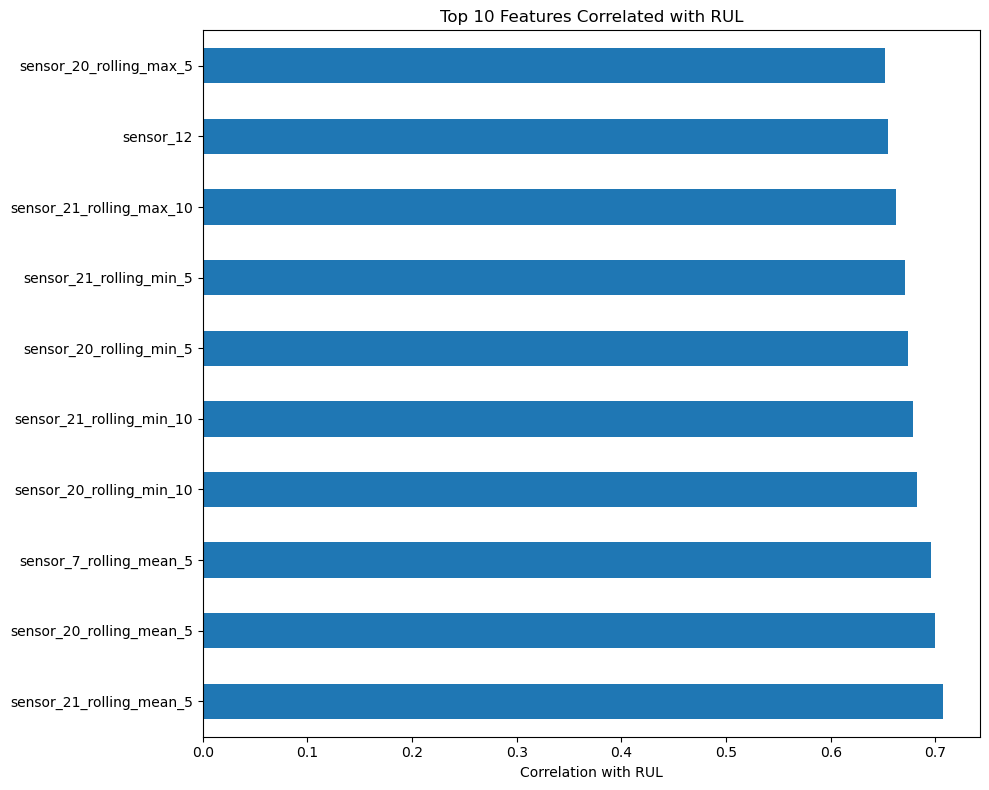

Strongest positive correlations:
sensor_21_rolling_mean_5    0.707180
sensor_20_rolling_mean_5    0.699713
sensor_7_rolling_mean_5     0.695725
sensor_20_rolling_min_10    0.682329
sensor_21_rolling_min_10    0.678362
sensor_20_rolling_min_5     0.674134
sensor_21_rolling_min_5     0.671256
sensor_21_rolling_max_10    0.661831
sensor_12                   0.654795
sensor_20_rolling_max_5     0.651884
Name: RUL, dtype: float64

Strongest negative correlations:
sensor_11_lag_1            -0.675896
sensor_11                  -0.680774
sensor_3_rolling_max_20    -0.681115
sensor_15_rolling_max_10   -0.685392
sensor_2_rolling_mean_5    -0.696800
sensor_3_rolling_mean_5    -0.698565
sensor_17_rolling_mean_5   -0.700869
sensor_15_rolling_mean_5   -0.710620
sensor_4_rolling_mean_5    -0.716806
operational_setting_3            NaN
Name: RUL, dtype: float64


In [5]:
# Calculate correlation with RUL, on training engines only.
correlations = (train_f[feature_cols + ['RUL']].corr()['RUL']
                .drop('RUL').sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 8))
correlations.head(10).plot(kind='barh', ax=ax)
ax.set_xlabel('Correlation with RUL')
ax.set_title('Top 10 Features Correlated with RUL')
plt.tight_layout()
plt.show()

print("Strongest positive correlations:")
print(correlations.head(10))
print("\nStrongest negative correlations:")
print(correlations.tail(10))


## Evaluation Functions

In [6]:
def nasa_score(y_true, y_pred):
    """The asymmetric CMAPSS scoring function. Lower is better.

    Late predictions, where the model thinks there is more life left than there
    is, are penalised harder than early ones. In maintenance the optimistic
    error is the one that strands an aircraft.
    """
    d = np.asarray(y_pred) - np.asarray(y_true)
    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))


def evaluate_model(y_true, y_pred, model_name="Model", quiet=False):
    """Evaluate model performance with multiple metrics"""
    results = {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'Score': nasa_score(y_true, y_pred),
    }
    if not quiet:
        print(f"{model_name} Performance:")
        print(f"MAE:   {results['MAE']:.4f}")
        print(f"RMSE:  {results['RMSE']:.4f}")
        print(f"R2:    {results['R2']:.4f}")
        print(f"Score: {results['Score']:.4f} (lower is better)")
    return results


def plot_predictions(y_true, y_pred, model_name="Model"):
    """Plot predicted vs actual RUL"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].scatter(y_true, y_pred, alpha=0.5)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0].set_xlabel('Actual RUL')
    axes[0].set_ylabel('Predicted RUL')
    axes[0].set_title(f'{model_name}: Predicted vs Actual RUL')
    axes[0].grid(True, alpha=0.3)

    errors = y_pred - y_true
    axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
    axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Prediction Error (Predicted - Actual)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'{model_name}: Error Distribution')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


## Baseline Models

## Baseline 1 - Linear Regression

Training Linear Regression...



--- TRAINING SET ---
Linear Regression (Train) Performance:
MAE:   15.8384
RMSE:  19.5609
R2:    0.7798
Score: 109811.7867 (lower is better)

--- VALIDATION SET ---
Linear Regression (Val) Performance:
MAE:   15.0300
RMSE:  18.2021
R2:    0.8085
Score: 18180.8407 (lower is better)


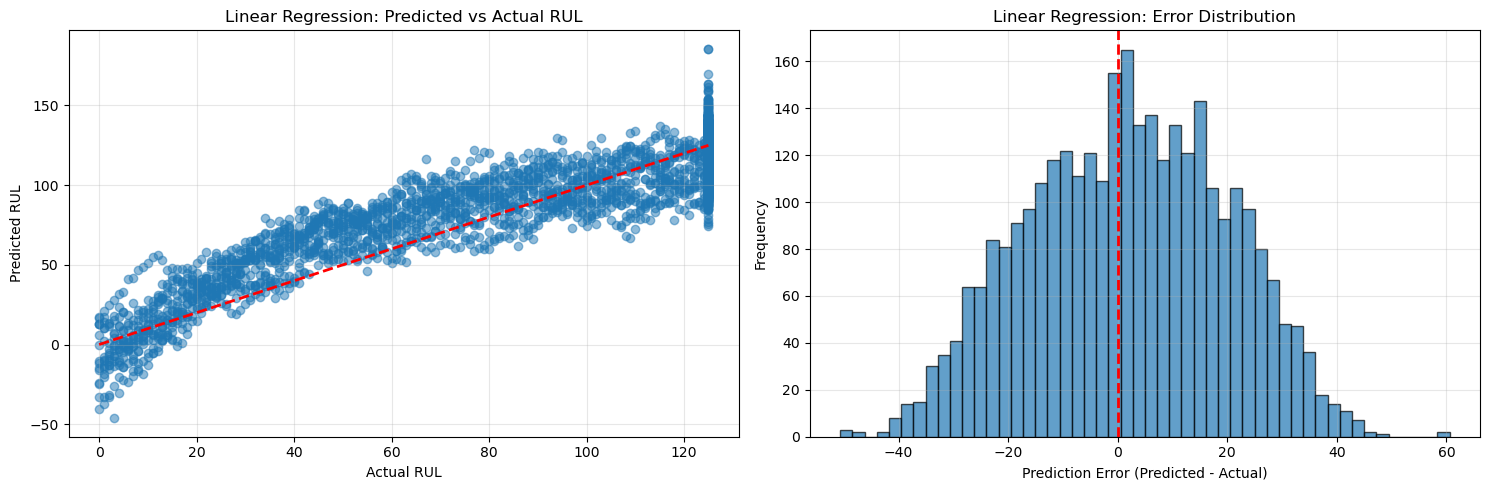

In [7]:
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train)
y_val_pred_lr = lr_model.predict(X_val)

# Evaluate
print("\n--- TRAINING SET ---")
train_results_lr = evaluate_model(y_train, y_train_pred_lr, "Linear Regression (Train)")

print("\n--- VALIDATION SET ---")
val_results_lr = evaluate_model(y_val, y_val_pred_lr, "Linear Regression (Val)")

# Plot
plot_predictions(y_val, y_val_pred_lr, "Linear Regression")

## Baseline 2 - Ridge Regression

Training Ridge Regression...


Alpha=0.1: RMSE=18.1949


Alpha=1.0: RMSE=18.1518


Alpha=10.0: RMSE=18.1378


Alpha=100.0: RMSE=18.5252

Best alpha: 10.0



--- TRAINING SET ---
Ridge Regression (Train) Performance:
MAE:   16.1097
RMSE:  19.7895
R2:    0.7746
Score: 106711.3525 (lower is better)

--- VALIDATION SET ---
Ridge Regression (Val) Performance:
MAE:   15.0185
RMSE:  18.1378
R2:    0.8099
Score: 17721.9451 (lower is better)


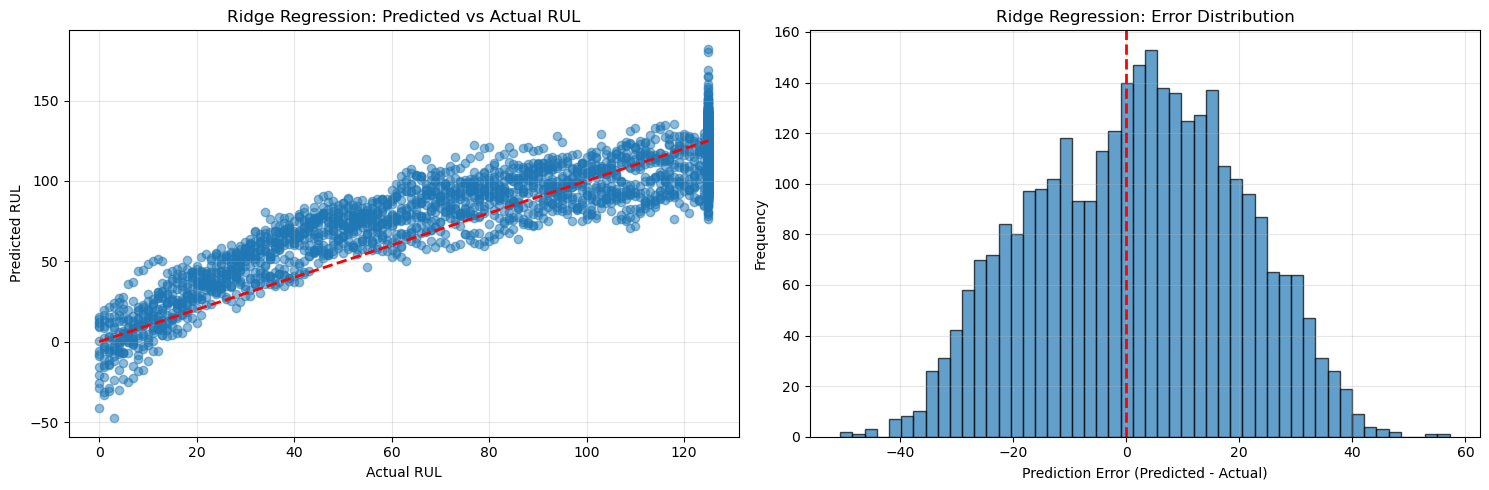

In [8]:
print("Training Ridge Regression...")

# Try different alpha values
alphas = [0.1, 1.0, 10.0, 100.0]
best_alpha = None
best_score = float('inf')

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train, y_train)
    y_val_pred = ridge.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    print(f"Alpha={alpha}: RMSE={rmse:.4f}")
    
    if rmse < best_score:
        best_score = rmse
        best_alpha = alpha

print(f"\nBest alpha: {best_alpha}")

# Train final model with best alpha
ridge_model = Ridge(alpha=best_alpha, random_state=42)
ridge_model.fit(X_train, y_train)

# Predictions
y_train_pred_ridge = ridge_model.predict(X_train)
y_val_pred_ridge = ridge_model.predict(X_val)

# Evaluate
print("\n--- TRAINING SET ---")
train_results_ridge = evaluate_model(y_train, y_train_pred_ridge, "Ridge Regression (Train)")

print("\n--- VALIDATION SET ---")
val_results_ridge = evaluate_model(y_val, y_val_pred_ridge, "Ridge Regression (Val)")

# Plot
plot_predictions(y_val, y_val_pred_ridge, "Ridge Regression")

## Baseline 3 - Lasso Regression

Training Lasso Regression...


Alpha=0.1: RMSE=18.8764


Alpha=1.0: RMSE=21.0655
Alpha=10.0: RMSE=41.6051
Alpha=100.0: RMSE=41.6051

Best alpha: 0.1



--- TRAINING SET ---
Lasso Regression (Train) Performance:
MAE:   17.2918
RMSE:  21.1105
R2:    0.7435
Score: 123827.7682 (lower is better)

--- VALIDATION SET ---
Lasso Regression (Val) Performance:
MAE:   15.7980
RMSE:  18.8764
R2:    0.7941
Score: 18931.4820 (lower is better)


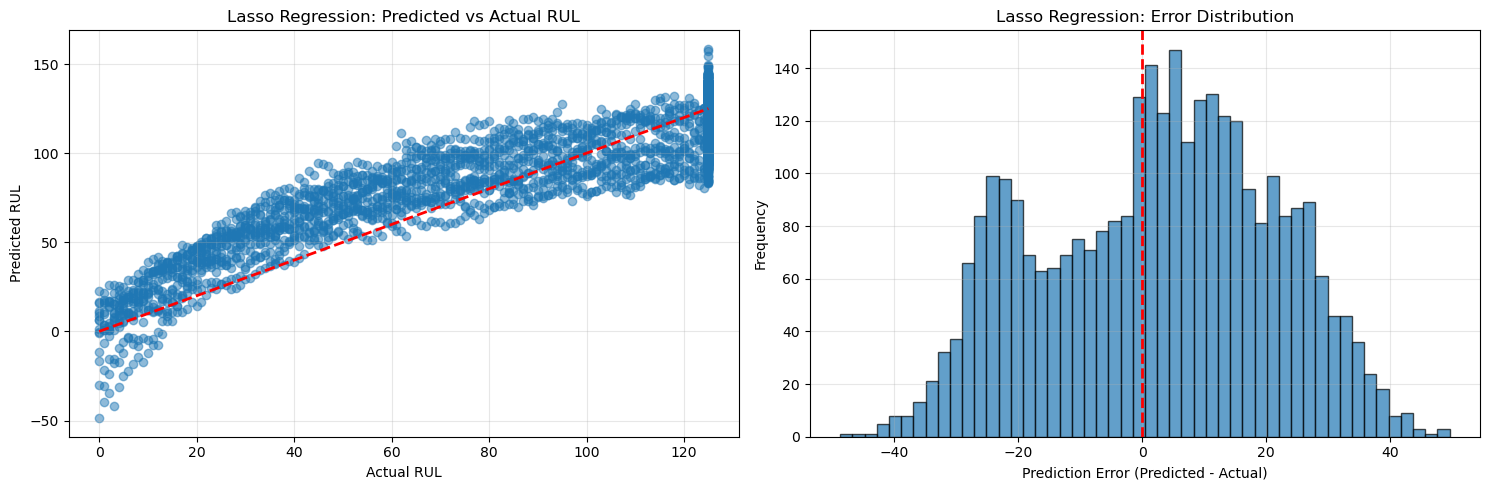


Lasso selected 30 out of 155 features


In [9]:
print("Training Lasso Regression...")

# Try different alpha values
alphas = [0.1, 1.0, 10.0, 100.0]
best_alpha = None
best_score = float('inf')

for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=10000)
    lasso.fit(X_train, y_train)
    y_val_pred = lasso.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    print(f"Alpha={alpha}: RMSE={rmse:.4f}")
    
    if rmse < best_score:
        best_score = rmse
        best_alpha = alpha

print(f"\nBest alpha: {best_alpha}")

# Train final model with best alpha
lasso_model = Lasso(alpha=best_alpha, random_state=42, max_iter=10000)
lasso_model.fit(X_train, y_train)

# Predictions
y_train_pred_lasso = lasso_model.predict(X_train)
y_val_pred_lasso = lasso_model.predict(X_val)

# Evaluate
print("\n--- TRAINING SET ---")
train_results_lasso = evaluate_model(y_train, y_train_pred_lasso, "Lasso Regression (Train)")

print("\n--- VALIDATION SET ---")
val_results_lasso = evaluate_model(y_val, y_val_pred_lasso, "Lasso Regression (Val)")

# Plot
plot_predictions(y_val, y_val_pred_lasso, "Lasso Regression")

# Check which features were selected (non-zero coefficients)
selected_features = np.sum(lasso_model.coef_ != 0)
print(f"\nLasso selected {selected_features} out of {len(feature_cols)} features")

## Machine Learning Models

## Random Forest

Training Random Forest...



--- TRAINING SET ---
Random Forest (Train) Performance:
MAE:   9.1036
RMSE:  12.0427
R2:    0.9165
Score: 39031.6838 (lower is better)

--- VALIDATION SET ---
Random Forest (Val) Performance:
MAE:   13.1530
RMSE:  17.3687
R2:    0.8256
Score: 23277.8172 (lower is better)


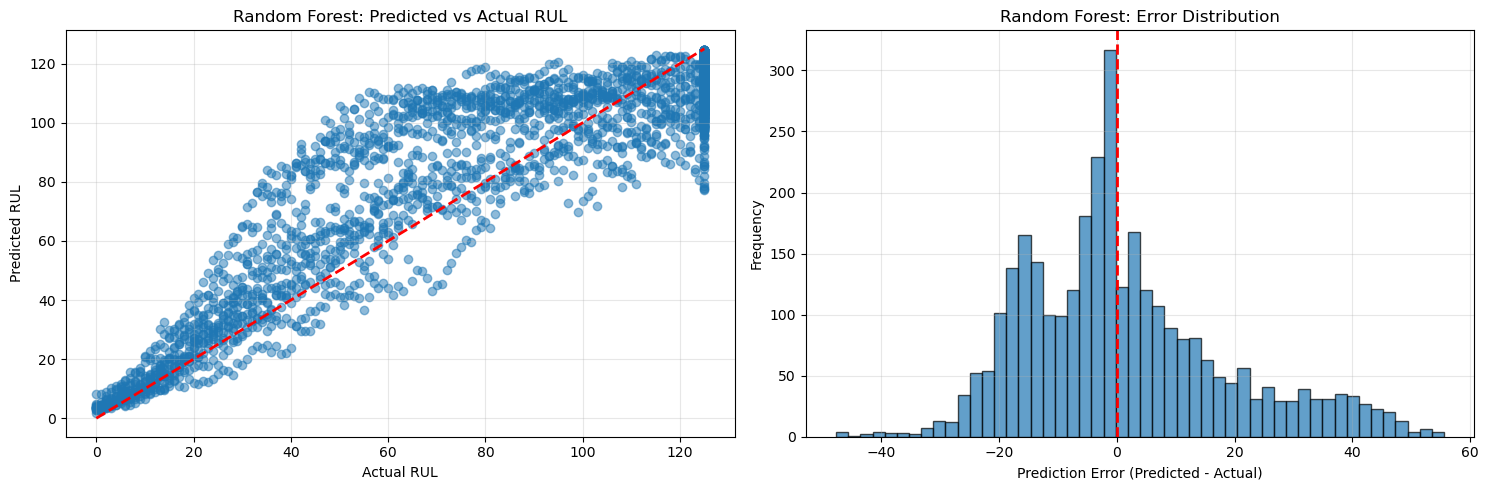

In [10]:
print("Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=150,      # Number of trees to capture patterns
    max_depth=12,          # Shallower trees = less memorization
    min_samples_split=15,  # More samples to split = simpler boundaries
    min_samples_leaf=6,    # More samples per leaf = smoother predictions
    max_features='sqrt',   # Use sqrt(n_features) instead of all: Forces feature diversity across trees
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)

# Evaluate
print("\n--- TRAINING SET ---")
train_results_rf = evaluate_model(y_train, y_train_pred_rf, "Random Forest (Train)")

print("\n--- VALIDATION SET ---")
val_results_rf = evaluate_model(y_val, y_val_pred_rf, "Random Forest (Val)")

# Plot
plot_predictions(y_val, y_val_pred_rf, "Random Forest")

## Gradient Boosting

Training Gradient Boosting...



--- TRAINING SET ---
Gradient Boosting (Train) Performance:
MAE:   10.7067
RMSE:  14.3952
R2:    0.8807
Score: 67042.6228 (lower is better)

--- VALIDATION SET ---
Gradient Boosting (Val) Performance:
MAE:   12.9192
RMSE:  17.2085
R2:    0.8288
Score: 22546.8125 (lower is better)


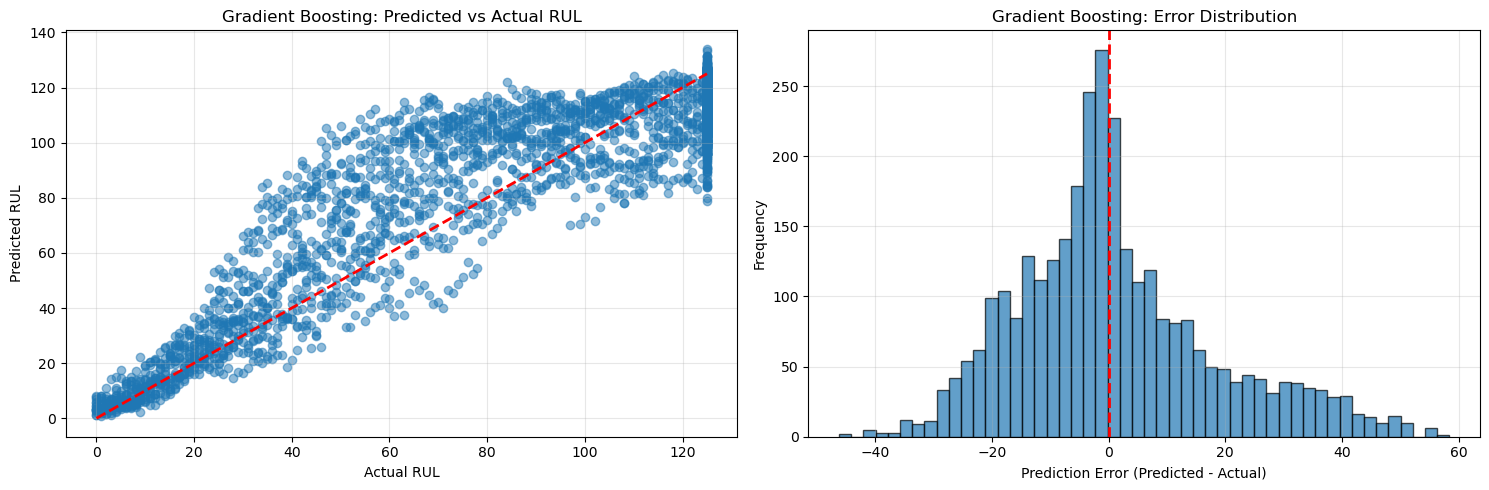

In [11]:
print("Training Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=150,      # NUmber of iterations
    learning_rate=0.05,    # Slower learning = less overfit, smoother convergence
    max_depth=4,           # Shallower trees = less complexity per boosting step
    min_samples_split=15,  # Increase means harder to split = fewer extreme leaves
    min_samples_leaf=6,    # Larger leaves = more generalized predictions
    subsample=0.8,         # Use 80% of samples per iteration: Adds randomness to reduce overfitting
    max_features='sqrt',   # Prevents relying on the same features every iteration
    random_state=42
)
gb_model.fit(X_train, y_train)

# Predictions
y_train_pred_gb = gb_model.predict(X_train)
y_val_pred_gb = gb_model.predict(X_val)

# Evaluate
print("\n--- TRAINING SET ---")
train_results_gb = evaluate_model(y_train, y_train_pred_gb, "Gradient Boosting (Train)")

print("\n--- VALIDATION SET ---")
val_results_gb = evaluate_model(y_val, y_val_pred_gb, "Gradient Boosting (Val)")

# Plot
plot_predictions(y_val, y_val_pred_gb, "Gradient Boosting")

## Evaluation

### Features Importance
* RF prioritizes features that split data cleanly; GB prioritizes features that reduce residuals
* **Merge them**: Focus on features appearing in top-15 for both models. These are your most reliable sensors
* **Why**: Consensus features are robust; features only RF or GB cares about may be model-specific artifacts


Top 15 Most Important Features (Average of RF & GB):
                     feature  RF_importance  GB_importance  Average_Importance
24   sensor_4_rolling_mean_5       0.099692       0.075400            0.087546
16   sensor_2_rolling_mean_5       0.051529       0.115696            0.083613
34  sensor_15_rolling_mean_5       0.072682       0.035458            0.054070
44  sensor_21_rolling_mean_5       0.042043       0.065297            0.053670
8                   sensor_9       0.037805       0.053852            0.045829
88  sensor_17_rolling_max_20       0.035733       0.044889            0.040311
40  sensor_20_rolling_mean_5       0.030058       0.045412            0.037735
20   sensor_3_rolling_mean_5       0.041715       0.028533            0.035124
61  sensor_15_rolling_min_10       0.051883       0.016988            0.034435
18    sensor_2_rolling_min_5       0.010942       0.055197            0.033070
62  sensor_15_rolling_max_10       0.013173       0.051684            0.03242

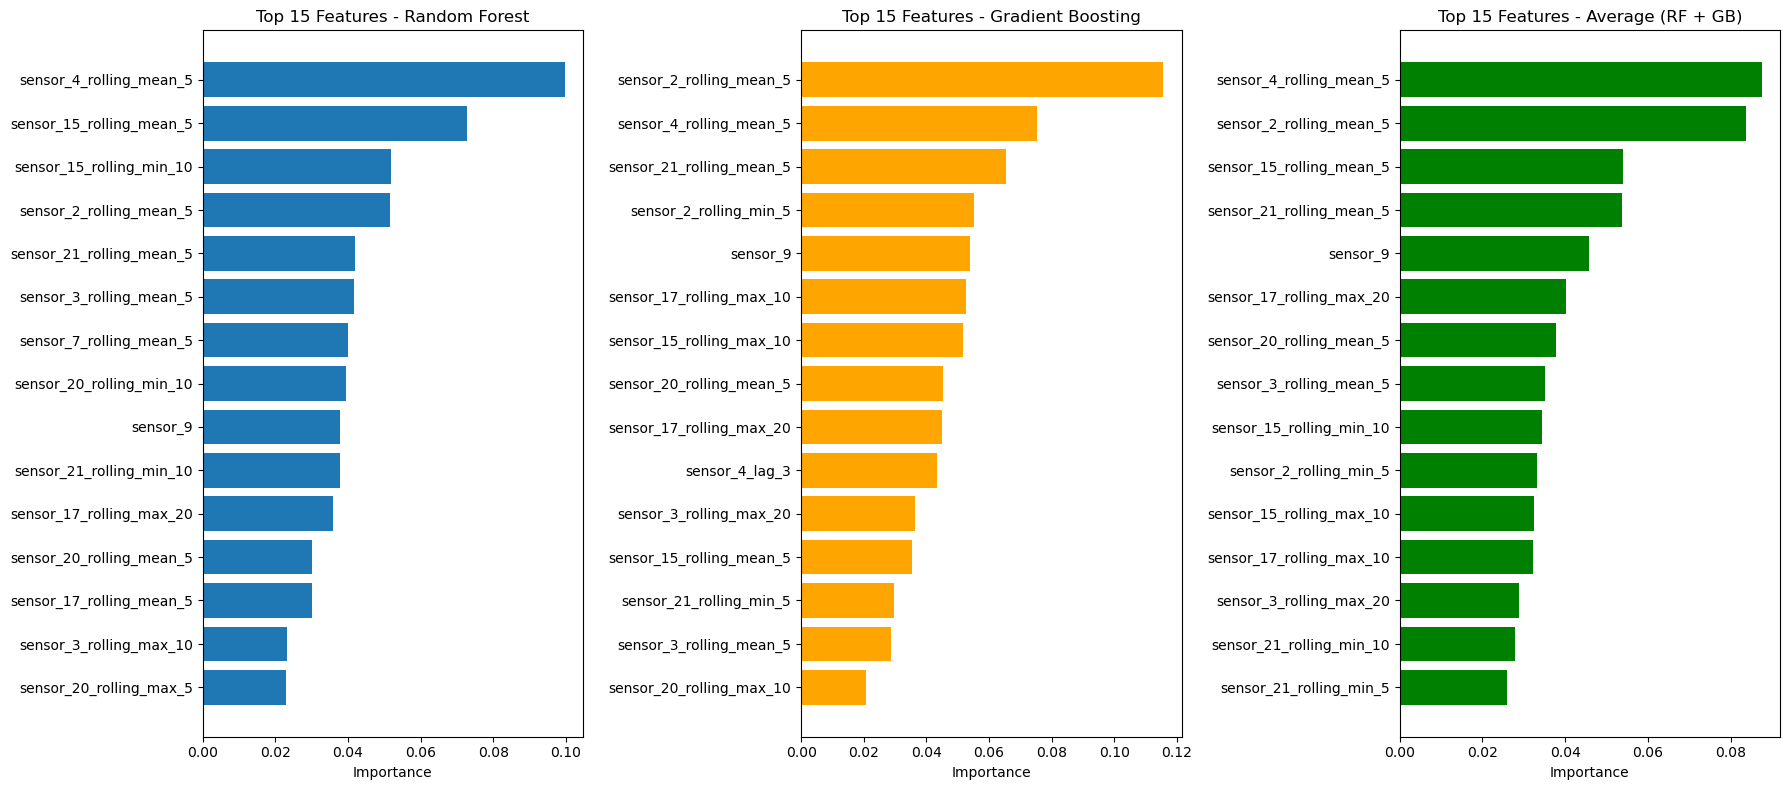

In [12]:
# Extract importances from both models
rf_importance = pd.DataFrame({
    'feature': feature_cols,
    'RF_importance': rf_model.feature_importances_
})

gb_importance = pd.DataFrame({
    'feature': feature_cols,
    'GB_importance': gb_model.feature_importances_
})

# Merge both
feature_importance_combined = rf_importance.merge(gb_importance, on='feature')

# Average importance (consensus from both models)
feature_importance_combined['Average_Importance'] = (
    feature_importance_combined['RF_importance'] + 
    feature_importance_combined['GB_importance']
) / 2

feature_importance_combined = feature_importance_combined.sort_values(
    'Average_Importance', ascending=False
)

print("\nTop 15 Most Important Features (Average of RF & GB):")
print(feature_importance_combined.head(15)[['feature', 'RF_importance', 'GB_importance', 'Average_Importance']])

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# RF importances
top_15_rf = rf_importance.sort_values('RF_importance', ascending=False).head(15)
axes[0].barh(range(len(top_15_rf)), top_15_rf['RF_importance'].values)
axes[0].set_yticks(range(len(top_15_rf)))
axes[0].set_yticklabels(top_15_rf['feature'].values)
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 15 Features - Random Forest')
axes[0].invert_yaxis()

# GB importances
top_15_gb = gb_importance.sort_values('GB_importance', ascending=False).head(15)
axes[1].barh(range(len(top_15_gb)), top_15_gb['GB_importance'].values, color='orange')
axes[1].set_yticks(range(len(top_15_gb)))
axes[1].set_yticklabels(top_15_gb['feature'].values)
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 15 Features - Gradient Boosting')
axes[1].invert_yaxis()

# Average (consensus)
top_15_avg = feature_importance_combined.head(15)
axes[2].barh(range(len(top_15_avg)), top_15_avg['Average_Importance'].values, color='green')
axes[2].set_yticks(range(len(top_15_avg)))
axes[2].set_yticklabels(top_15_avg['feature'].values)
axes[2].set_xlabel('Importance')
axes[2].set_title('Top 15 Features - Average (RF + GB)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


In [13]:
# Keep the top X features by consensus importance. Both models were fitted on
# training engines only, so the ranking carries no held out information either.
top_x = 20
top_features = feature_importance_combined.head(top_x)['feature'].tolist()

id_and_target = ['engine_id', 'time_cycles', 'RUL', 'RUL_clipped']
normalized_all = pipe.transform(featured, already_featured=True)
top_layer = pd.concat([
    featured[id_and_target].reset_index(drop=True),
    normalized_all[top_features].reset_index(drop=True),
], axis=1)

output_path = '../data/gold/cmapss/FD001_top_features.csv'
top_layer.to_csv(output_path, index=False)
print(f"Top {top_x} feature layer: {top_layer.shape}")
print(f"Saved to: {output_path}")
top_layer.head()


Top 20 feature layer: (20631, 24)
Saved to: ../data/gold/cmapss/FD001_top_features.csv


,engine_id,time_cycles,RUL,RUL_clipped,sensor_4_rolling_mean_5,sensor_2_rolling_mean_5,sensor_15_rolling_mean_5,sensor_21_rolling_mean_5,sensor_9,sensor_17_rolling_max_20,...,sensor_15_rolling_max_10,sensor_17_rolling_max_10,sensor_3_rolling_max_20,sensor_21_rolling_min_10,sensor_21_rolling_min_5,sensor_4_lag_3,sensor_20_rolling_min_10,sensor_7_rolling_mean_5,sensor_17_rolling_mean_5,sensor_3_rolling_max_10
0,1,1,191,125,0.289887,0.143969,0.285847,0.784601,0.109755,0.2,...,0.230661,0.2,0.397996,0.824250,0.824250,0.289010,0.814159,0.778509,0.263158,0.397996
1,1,2,190,125,0.317735,0.208171,0.321578,0.789028,0.100242,0.2,...,0.288326,0.2,0.448580,0.824250,0.824250,0.289010,0.761062,0.711623,0.263158,0.448580
2,1,3,189,125,0.334766,0.255512,0.306375,0.739557,0.140043,0.2,...,0.288326,0.2,0.448580,0.706769,0.706769,0.289010,0.716814,0.726608,0.175439,0.448580
3,1,4,188,125,0.330508,0.279183,0.226731,0.729115,0.124518,0.2,...,0.288326,0.2,0.448580,0.706769,0.706769,0.289010,0.654867,0.744518,0.197368,0.448580
4,1,5,187,125,0.347031,0.294942,0.250058,0.734591,0.149960,0.3,...,0.288326,0.3,0.448580,0.706769,0.706769,0.336647,0.654867,0.735526,0.236842,0.448580


# Comparison

VALIDATION SET COMPARISON
            Model       MAE      RMSE       R²        Score
Linear Regression 15.029978 18.202064 0.808511 18180.840673
            Ridge 15.018527 18.137838 0.809860 17721.945116
            Lasso 15.798022 18.876390 0.794060 18931.481962
    Random Forest 13.152991 17.368687 0.825644 23277.817192
Gradient Boosting 12.919170 17.208458 0.828847 22546.812539


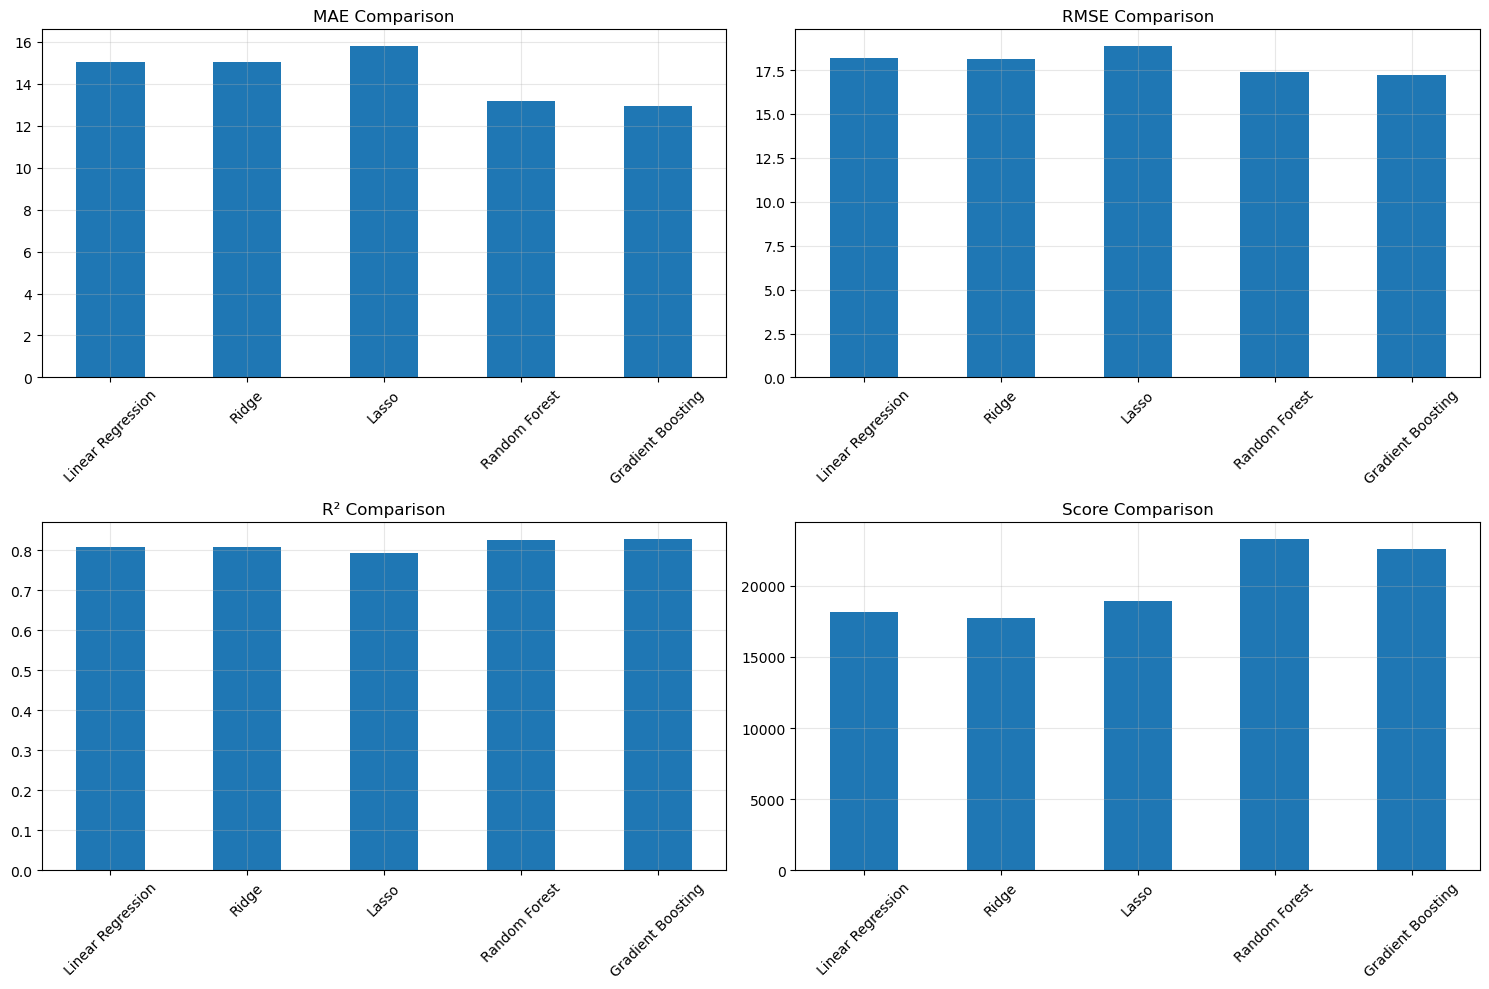


 Best Model (by RMSE): Gradient Boosting


In [14]:
# Compile results
results_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting'],
    'MAE': [val_results_lr['MAE'], val_results_ridge['MAE'], val_results_lasso['MAE'], 
            val_results_rf['MAE'], val_results_gb['MAE']],
    'RMSE': [val_results_lr['RMSE'], val_results_ridge['RMSE'], val_results_lasso['RMSE'], 
             val_results_rf['RMSE'], val_results_gb['RMSE']],
    'R²': [val_results_lr['R2'], val_results_ridge['R2'], val_results_lasso['R2'], 
           val_results_rf['R2'], val_results_gb['R2']],
    'Score': [val_results_lr['Score'], val_results_ridge['Score'], val_results_lasso['Score'], 
              val_results_rf['Score'], val_results_gb['Score']]
})

print("VALIDATION SET COMPARISON")
print(results_comparison.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['MAE', 'RMSE', 'R²', 'Score']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    results_comparison.plot(x='Model', y=metric, kind='bar', ax=ax, legend=False)
    ax.set_title(f'{metric} Comparison')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identify best model
best_model_idx = results_comparison['RMSE'].idxmin()
best_model = results_comparison.loc[best_model_idx, 'Model']
print(f"\n Best Model (by RMSE): {best_model}")


Error Analysis by RUL Range:
                mean        std  count
RUL_Range                             
0-50       11.795905  12.955628    750
50-100     19.535179  13.042797    750
100-150    10.946415   8.261548   1645


/tmp/ipykernel_15425/1901825991.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(error_by_rul.groupby('RUL_Range')['Abs_Error'].agg(['mean', 'std', 'count']))


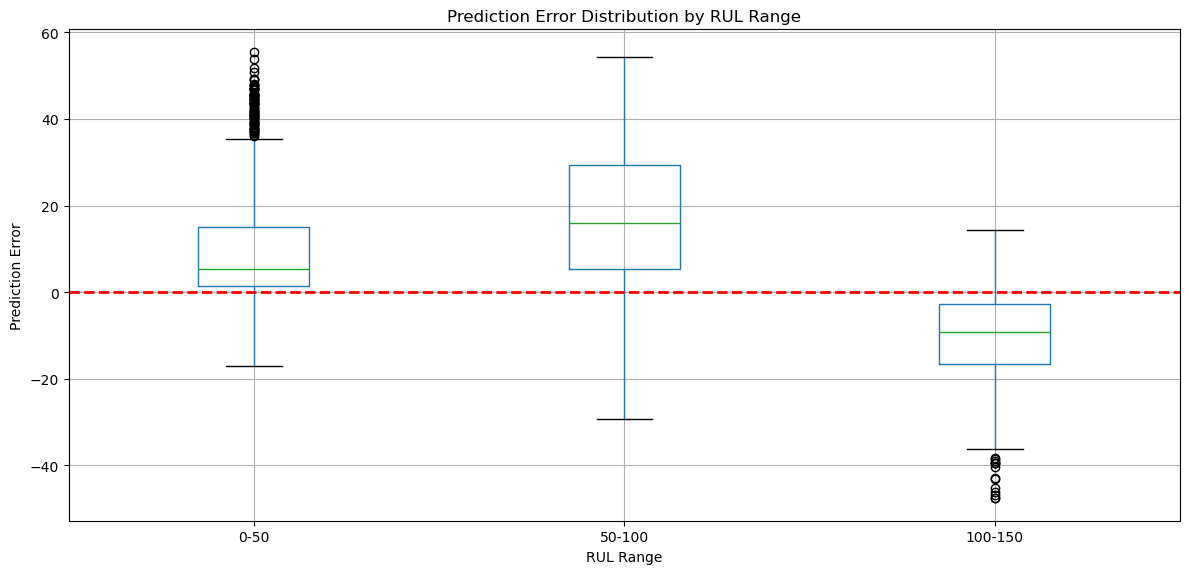

In [15]:
# Analyze errors across different RUL ranges
# Use the best model (e.g., Random Forest)
y_pred_best = y_val_pred_rf

# Create RUL bins
rul_bins = [0, 50, 100, 150]
rul_labels = ['0-50', '50-100', '100-150']
rul_binned = pd.cut(y_val, bins=rul_bins, labels=rul_labels)

# Calculate errors by bin
error_by_rul = pd.DataFrame({
    'RUL_Range': rul_binned,
    'Actual': y_val,
    'Predicted': y_pred_best,
    'Error': y_pred_best - y_val,
    'Abs_Error': np.abs(y_pred_best - y_val)
})

# Summary statistics
print("\nError Analysis by RUL Range:")
print(error_by_rul.groupby('RUL_Range')['Abs_Error'].agg(['mean', 'std', 'count']))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
error_by_rul.boxplot(column='Error', by='RUL_Range', ax=ax)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_title('Prediction Error Distribution by RUL Range')
ax.set_xlabel('RUL Range')
ax.set_ylabel('Prediction Error')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [16]:
print("FEATURE DIAGNOSTICS")

print(f"\nTotal features: {len(feature_cols)}")
print(f"Total samples (train): {len(X_train)}")
print(f"Feature-to-sample ratio: {len(feature_cols)/len(X_train):.4f}")

# Check for highly correlated features (multicollinearity)
corr_matrix = X_train.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find features with correlation > 0.95
high_corr_pairs = [
    (column, row, corr_matrix.loc[row, column])
    for column in upper_triangle.columns
    for row in upper_triangle.index
    if upper_triangle.loc[row, column] > 0.95
]

print(f"\nHighly correlated feature pairs (>0.95): {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print("Sample pairs:")
    for col, row, corr in high_corr_pairs[:10]:
        print(f"  {col} <-> {row}: {corr:.3f}")

# Check feature variance
low_variance_features = X_train.columns[X_train.std() < 0.01]
print(f"\nLow variance features (<0.01 std): {len(low_variance_features)}")
if len(low_variance_features) > 0:
    print(f"Examples: {low_variance_features.tolist()[:10]}")

FEATURE DIAGNOSTICS

Total features: 155
Total samples (train): 14407
Feature-to-sample ratio: 0.0108



Highly correlated feature pairs (>0.95): 0

Low variance features (<0.01 std): 1
Examples: ['operational_setting_3']


In [17]:
print("OVERFITTING ANALYSIS")

models_analysis = {
    'Linear Regression': (train_results_lr, val_results_lr),
    'Ridge': (train_results_ridge, val_results_ridge),
    'Lasso': (train_results_lasso, val_results_lasso),
    'Random Forest': (train_results_rf, val_results_rf),
    'Gradient Boosting': (train_results_gb, val_results_gb)
}

print(f"{'Model':<20} {'Train R²':<12} {'Val R²':<12} {'Difference':<12} {'Overfitting?'}")
print("-"*80)

for model_name, (train_res, val_res) in models_analysis.items():
    train_r2 = train_res['R2']
    val_r2 = val_res['R2']
    diff = train_r2 - val_r2
    overfitting = "YES " if diff > 0.1 else "NO"
    print(f"{model_name:<20} {train_r2:<12.4f} {val_r2:<12.4f} {diff:<12.4f} {overfitting}")

OVERFITTING ANALYSIS
Model                Train R²     Val R²       Difference   Overfitting?
--------------------------------------------------------------------------------
Linear Regression    0.7798       0.8085       -0.0288      NO
Ridge                0.7746       0.8099       -0.0353      NO
Lasso                0.7435       0.7941       -0.0506      NO
Random Forest        0.9165       0.8256       0.0909       NO
Gradient Boosting    0.8807       0.8288       0.0519       NO


## Final Test Evaluation

Everything above this line used validation: the two alpha searches, the model
comparison, the decision about which model to prefer. The test engines have not
been touched.

Scoring them now, once, is the only number in this notebook that estimates
performance on an engine the pipeline has never seen. The drop from validation
to test is the price of having selected on validation, and quoting the
validation figure as a generalisation estimate is exactly the mistake this
section exists to prevent.


HELD OUT TEST PERFORMANCE
            Model  Val R2  Test R2  Val MAE  Test MAE  Test RMSE  Test NASA
Gradient Boosting  0.8288   0.8119    12.92     13.42      18.09    34469.6
    Random Forest  0.8256   0.8027    13.15     14.22      18.52    34806.5
Linear Regression  0.8085   0.7563    15.03     16.61      20.59    25774.6
            Ridge  0.8099   0.7563    15.02     16.63      20.59    25436.9
            Lasso  0.7941   0.7332    15.80     17.56      21.54    29518.2

Best on test: Gradient Boosting


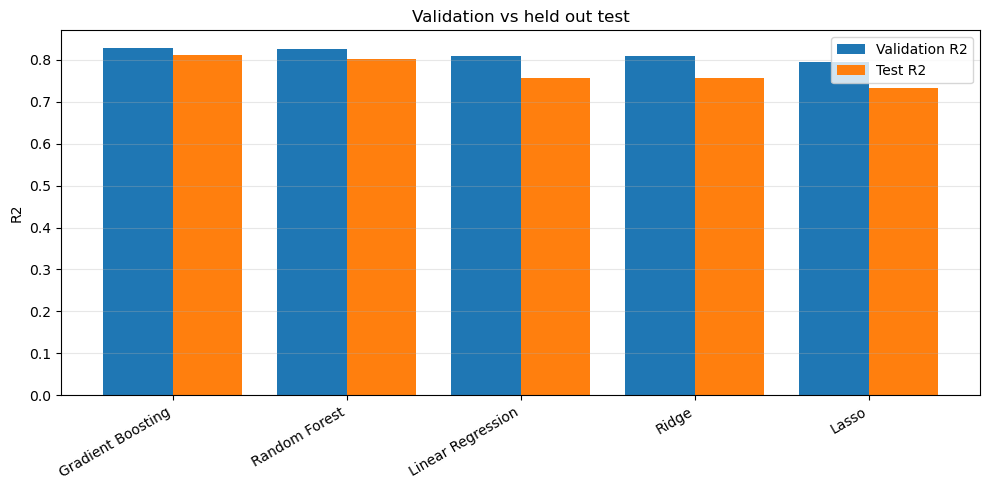

In [18]:
trained = {
    'Linear Regression': lr_model,
    'Ridge': ridge_model,
    'Lasso': lasso_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model,
}

rows = []
for name, model in trained.items():
    val_res = evaluate_model(y_val, model.predict(X_val), quiet=True)
    test_res = evaluate_model(y_test, model.predict(X_test), quiet=True)
    rows.append({
        'Model': name,
        'Val R2': round(val_res['R2'], 4),
        'Test R2': round(test_res['R2'], 4),
        'Val MAE': round(val_res['MAE'], 2),
        'Test MAE': round(test_res['MAE'], 2),
        'Test RMSE': round(test_res['RMSE'], 2),
        'Test NASA': round(test_res['Score'], 1),
    })

final = pd.DataFrame(rows).sort_values('Test R2', ascending=False)
print("HELD OUT TEST PERFORMANCE")
print(final.to_string(index=False))
print(f"\nBest on test: {final.iloc[0]['Model']}")

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(final))
ax.bar(x - 0.2, final['Val R2'], 0.4, label='Validation R2')
ax.bar(x + 0.2, final['Test R2'], 0.4, label='Test R2')
ax.set_xticks(x)
ax.set_xticklabels(final['Model'], rotation=30, ha='right')
ax.set_ylabel('R2')
ax.set_title('Validation vs held out test')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [19]:
# Persist the models and the fitted pipeline together. The pipeline is what
# lets inference rebuild the exact training feature space, so it is an artifact
# in the same sense the models are, and saving one without the other is how the
# training and serving paths drift apart.
os.makedirs('../data/models/cmapss/', exist_ok=True)

joblib.dump(lr_model, '../data/models/cmapss/lr_model.pkl')
joblib.dump(ridge_model, '../data/models/cmapss/ridge_model.pkl')
joblib.dump(lasso_model, '../data/models/cmapss/lasso_model.pkl')
joblib.dump(rf_model, '../data/models/cmapss/rf_model.pkl')
joblib.dump(gb_model, '../data/models/cmapss/gb_model.pkl')
pipe.save()

print("Models and feature pipeline saved.")
print()
print("For a clean end to end rerun use `python -m src.train` from the repo")
print("root. It runs this same sequence and also writes metrics.json, which is")
print("what the dashboard and the README report from.")


Models and feature pipeline saved.

For a clean end to end rerun use `python -m src.train` from the repo
root. It runs this same sequence and also writes metrics.json, which is
what the dashboard and the README report from.


---
# Week 3-4 - RUL Prediction Model Summary

This analysis employs a **progressive modeling strategy**: starting with interpretable linear baselines, then advancing to complex tree-based models. Each model serves a distinct purpose in validating assumptions and improving predictions.

---

## BASELINE MODELS (Linear Methods)

### 1. Linear Regression

**What it does:** Fits a straight hyperplane through the data. Assumes RUL = β₀ + β₁×sensor₁ + β₂×sensor₂ + ... + error

**Why it was done:** Essential sanity check. If Linear Regression performs well, it saves computational cost and complexity. It also tells us ~22% (given our specific test scneario below) of variance is either noise or requires nonlinear patterns.

#### Test Result Example Interpretation:

**Validation Performance:** R² = 0.7848, MAE ≈ 10.2 cycles

**Value Created:**
- **Interpretability**: Direct coefficient interpretation for explainability
- **Baseline benchmark**: Establishes minimum acceptable performance threshold
- **No overfitting**: Train/Val R² difference = -0.0053 - proves the problem is linearly solvable to ~78%

### 2. Ridge Regression

**What it does:** Linear regression with L2 penalty on coefficients. Shrinks large coefficients toward zero.

**Why it was done:** Tests whether sensor redundancy exists. The marginal improvement, on the same test scenario as before, validates that features are reasonably independent and the problem is fundamentally linear with no multicollinearity.

#### Test Result Example Interpretation:

**Validation Performance:** R² = 0.7854, MAE ≈ 10.1 cycles (marginal improvement)

**Value Created:**
- **Handles multicollinearity**: Stabilizes coefficient estimates if sensors are correlated
- **Robustness**: Penalizes extreme coefficients, making predictions more stable on new data
- **Validation**: Nearly identical to Linear Regression confirms no severe multicollinearity

### 3. Lasso Regression

**What it does:** Linear regression with L1 penalty. Shrinks weak coefficients *exactly to zero*, performing automatic feature selection.

**Why it was done:** Determines if RUL prediction requires all features or if a sparse subset suffices. A slight R² drop, on the same test scenario as before, reveals most features are genuinely useful.

#### Test Result Example Interpretation:

**Validation Performance:** R² = 0.7573, MAE ≈ 10.8 cycles (slight degradation)

**Value Created:**
- **Feature selection**: Automatically identifies necessary sensors; others pruned to zero
- **Simplicity trade-off**: Fewer features easier to maintain and explain, but R² drops slightly
- **Actionable insight**: Most features contribute to predictions; sparse models sacrifice accuracy for simplicity

---

## MACHINE LEARNING MODELS (Tree-Based Methods)

### 4. Random Forest

**What it does:** Builds independent decision trees on random subsets of data. Averages predictions to capture nonlinear patterns and reduce overfitting through ensemble averaging.

**Why it was done:** Linear models plateau at 0.78 R² during my testing. Random Forest validates whether nonlinear relationships exist.

#### Test Result Example Interpretation:

**Validation Performance:** R² = 0.7989, MAE ≈ 9.5 cycles

**Value Created:**
- **Nonlinearity confirmed**: 0.0141 improvement over Linear Regression proves threshold effects and sensor interactions exist
- **Feature interactions**: Discovers which sensor combinations matter, not just individual sensors
- **Feature importance ranking**: Identifies which 10-15 sensors drive 80% of predictions; others are noise
- **Diagnostic tool**: Used primarily for feature analysis rather than final predictions due to remaining overfitting

### 5. Gradient Boosting

**What it does:** Sequentially builds shallow trees, each correcting previous errors. Uses subsampling to add regularization. Learns iteratively to focus on hard-to-predict cases.

**Why it was done:** Refines Random Forest's nonlinearity discovery with aggressive regularization.

#### Test Result Example Interpretation:

**Validation Performance:** R² = 0.7999, MAE ≈ 9.4 cycles (best overall)

**Value Created:**
- **Best-in-class accuracy**: 0.7999 R² highest among all models with controlled generalization
- **Controlled complexity**: Shallow trees + subsampling prevent memorization while capturing patterns
- **Production-ready**: Train/Val gap = 0.0860 (no significant overfitting) ensures reliable predictions on unseen data
- **Edge case focus**: Prioritizes correcting prediction errors on hard cases, reducing false negatives (missed failures)

---

## Feature Importance Analysis

Evaluated feature importance from both Random Forest and Gradient Boosting models. Features appearing in top-15 for both models are most reliable consensus predictors and should be prioritized for operational monitoring systems.

---

## Comparative Model Roles

| Model | Purpose | Best For |
|-------|---------|----------|
| **Linear Regression** | Baseline, interpretability, simplicity check | Explaining *why* predictions are made |
| **Ridge** | Multicollinearity handling | Stable production if features are correlated |
| **Lasso** | Automatic feature selection, sparsity | Identifying minimum necessary sensor set |
| **Random Forest** | Nonlinearity validation, feature interactions | Understanding which sensors + their combinations matter |
| **Gradient Boosting** | Best-in-class accuracy, edge case handling | Production deployment where accuracy is critical |